# Clase 04 — Data Cleaning + Linear Regression

**Analítica de Datos · Negocios Digitales**

## Contexto de negocio

Somos el equipo de datos de una empresa de e-commerce. El equipo de **marketing** nos pasó un dataset con la inversión publicitaria diaria por canal (Instagram, Facebook, Google Ads, TikTok) y las ventas atribuidas. 

## Pregunta de negocio

> **¿Cuántos dólares de venta generamos, en promedio, por cada dólar invertido en marketing digital? ¿Podemos predecir las ventas a partir de la inversión?**


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

df = pd.read_csv("campañas_marketing.csv")
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.info()
df.head()

Filas: 93  |  Columnas: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fecha          93 non-null     object 
 1   canal          93 non-null     object 
 2   region         93 non-null     object 
 3   inversion_usd  88 non-null     object 
 4   impresiones    93 non-null     int64  
 5   clicks         89 non-null     float64
 6   ventas_usd     93 non-null     float64
dtypes: float64(2), int64(1), object(4)
memory usage: 5.2+ KB


,fecha,canal,region,inversion_usd,impresiones,clicks,ventas_usd
0,2025-01-01,ig,capital,1980.10,42990,785.0,7004.58
1,2025-01-02,facebook,CABA,"$1,209",39055,1132.0,4526.43
2,2025-01-03,instagram,GBA,"$2,174.78",167043,2570.0,7692.18
3,2025-01-04,google ads,GBA,"$1,804",15409,588.0,6238.17
4,2025-01-05,google ads,caba,$416.61,88705,3288.0,1685.00


# Parte A — Data Cleaning

## A.1 Diagnóstico

Antes de tocar nada, observamos qué problemas tiene el dataset.

In [22]:
# Faltantes, categorías inconsistentes y duplicados
print("Nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print("\nCanales únicos:")
print(df["canal"].value_counts())
print("\nRegiones únicas:")
print(df["region"].value_counts())

Nulos por columna:
fecha            0
canal            0
region           0
inversion_usd    5
impresiones      0
clicks           4
ventas_usd       0
dtype: int64

Filas duplicadas: 3

Canales únicos:
canal
instagram     11
Google Ads    10
FB             9
google ads     8
Instagram      8
tik tok        8
facebook       7
IG             6
google_ads     5
ig             4
GoogleAds      4
Facebook       4
Tik Tok        4
TikTok         3
tiktok         2
Name: count, dtype: int64

Regiones únicas:
region
Interior    14
caba        13
CABA        12
GBA         11
gba         11
interior    11
Capital     11
capital     10
Name: count, dtype: int64


In [23]:
# Rangos de las variables numéricas
df.describe().round(2)

,impresiones,clicks,ventas_usd
count,93.00,89.00,93.00
mean,107117.46,2609.22,5305.23
std,55215.21,1763.65,4613.56
min,6379.00,163.00,1147.92
25%,60044.00,1177.00,3144.75
50%,107131.00,2261.00,4894.99
75%,159566.00,3901.00,6432.55
max,196962.00,6254.00,45000.00


→ El `max` de `ventas_usd` se va muy por encima del Q3. Lo confirmamos visualmente con un boxplot.

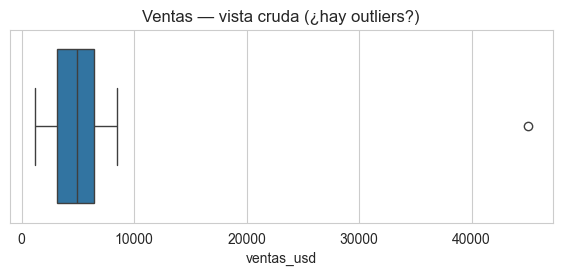

In [24]:
plt.figure(figsize=(7, 2.5))
sns.boxplot(x=df["ventas_usd"])
plt.title("Ventas — vista cruda (¿hay outliers?)")
plt.show()

In [25]:
# Formato de inversion_usd: viene como texto con $ y comas
print("Tipo de inversion_usd:", df["inversion_usd"].dtype)
print(df["inversion_usd"].head(6).tolist())

Tipo de inversion_usd: object
['1980.10', '$1,209', ' $2,174.78 ', '$1,804', ' $416.61 ', ' $2,443.93 ']


**Diagnóstico — encontramos 5 problemas.** Los resolvemos en el orden en que conviene atacarlos:

1. **Formato** de `inversion_usd` (viene como texto con `$` y comas) — primero, porque mientras sea texto no podemos imputar.
2. **Nulos** en `inversion_usd` y `clicks`.
3. **Categorías inconsistentes** en `canal` y `region` (mayúsculas, espacios, abreviaturas).
4. **Outlier extremo** en `ventas_usd`.
5. **Filas duplicadas**.

## A.2 Formato de `inversion_usd`

Lo arreglamos primero porque mientras sea texto no podemos imputar nulos numéricos.

In [26]:
# Sacamos $, USD, comas y espacios; lo que quede lo convertimos a número.
df["inversion_usd"] = (
    df["inversion_usd"]
    .str.replace("$", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["inversion_usd"] = pd.to_numeric(df["inversion_usd"], errors="coerce")

print("Nuevo tipo:", df["inversion_usd"].dtype)
df["inversion_usd"].describe()

Nuevo tipo: float64


count      88.000000
mean     1375.450114
std       645.798744
min       217.000000
25%       819.900000
50%      1412.615000
75%      1945.450000
max      2443.930000
Name: inversion_usd, dtype: float64

## A.3 Imputar nulos

Imputamos con la **mediana** (robusta a outliers).

In [27]:
for col in ["inversion_usd", "clicks"]:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"{col}: imputado con mediana = {mediana:.2f}")

print("\nNulos restantes:")
print(df.isnull().sum())

inversion_usd: imputado con mediana = 1412.62
clicks: imputado con mediana = 2261.00

Nulos restantes:
fecha            0
canal            0
region           0
inversion_usd    0
impresiones      0
clicks           0
ventas_usd       0
dtype: int64


## A.4 Normalizar categorías

Pasamos a minúscula, sacamos espacios, y mapeamos cada variante a un nombre canónico.

In [28]:
# Normalización base
df["canal"] = df["canal"].str.lower().str.strip()
df["region"] = df["region"].str.lower().str.strip()

# Diccionario de canales: variante -> nombre canónico
mapa_canal = {
    "instagram": "Instagram", "ig": "Instagram",
    "google ads": "Google Ads", "google_ads": "Google Ads", "googleads": "Google Ads",
    "tiktok": "TikTok", "tik tok": "TikTok",
    "facebook": "Facebook", "fb": "Facebook",
}
df["canal"] = df["canal"].map(mapa_canal)

# Diccionario de regiones
mapa_region = {
    "caba": "CABA", "capital": "CABA",
    "gba": "GBA",
    "interior": "Interior",
}
df["region"] = df["region"].map(mapa_region)

print("Canales después de normalizar:")
print(df["canal"].value_counts())
print("\nRegiones después de normalizar:")
print(df["region"].value_counts())

Canales después de normalizar:
canal
Instagram     29
Google Ads    27
Facebook      20
TikTok        17
Name: count, dtype: int64

Regiones después de normalizar:
region
CABA        46
Interior    25
GBA         22
Name: count, dtype: int64


## A.5 Outliers (método IQR)

Regla del rango intercuartílico: $Q_1 - 1.5 \cdot IQR$ y $Q_3 + 1.5 \cdot IQR$ son los límites aceptables.

Q1=3145  Q3=6433  IQR=3288
Límites aceptables: [-1787, 11364]
Filas antes: 93  →  después: 92  (1 outlier eliminado)


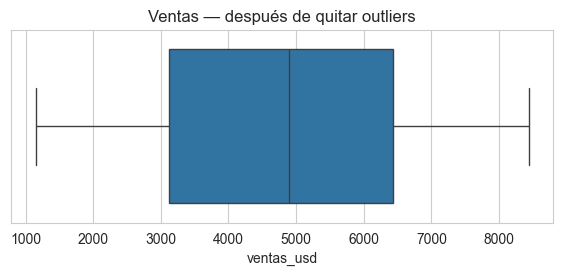

In [29]:
# Cálculo IQR
Q1 = df["ventas_usd"].quantile(0.25)
Q3 = df["ventas_usd"].quantile(0.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")
print(f"Límites aceptables: [{lim_inf:.0f}, {lim_sup:.0f}]")

# Detectar y filtrar outliers
n_antes = len(df)
df = df[(df["ventas_usd"] >= lim_inf) & (df["ventas_usd"] <= lim_sup)].copy()
print(f"Filas antes: {n_antes}  →  después: {len(df)}  ({n_antes - len(df)} outlier eliminado)")

# Boxplot después
plt.figure(figsize=(7, 2.5))
sns.boxplot(x=df["ventas_usd"])
plt.title("Ventas — después de quitar outliers")
plt.show()

## A.6 Duplicados

In [30]:
print(f"Duplicados antes: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicados después: {df.duplicated().sum()}")
print(f"Filas finales: {len(df)}")

Duplicados antes: 3
Duplicados después: 0
Filas finales: 89


## A.7 → `df_clean`

Verificamos y guardamos el DataFrame limpio para usarlo en la Parte B.

In [31]:
# Verificación final + DataFrame limpio listo para modelar
df_clean = df.copy()
print(f"df_clean listo: {df_clean.shape[0]} filas, {df_clean.shape[1]} columnas")
print(f"Nulos totales: {df_clean.isnull().sum().sum()}")
df_clean.head()

df_clean listo: 89 filas, 7 columnas
Nulos totales: 0


,fecha,canal,region,inversion_usd,impresiones,clicks,ventas_usd
0,2025-01-01,Instagram,CABA,1980.10,42990,785.0,7004.58
1,2025-01-02,Facebook,CABA,1209.00,39055,1132.0,4526.43
2,2025-01-03,Instagram,GBA,2174.78,167043,2570.0,7692.18
3,2025-01-04,Google Ads,GBA,1804.00,15409,588.0,6238.17
4,2025-01-05,Google Ads,CABA,416.61,88705,3288.0,1685.00


# Parte B — Regresión Lineal

Ya tenemos `df_clean`. Volvemos a la **pregunta de negocio** del principio: *¿cuántos USD de venta genera cada USD invertido en marketing? ¿Podemos predecirlo?* Para contestarla entrenamos una regresión lineal simple.

## B.1 EDA — correlaciones

Buscamos qué variable tiene la correlación más fuerte con `ventas_usd`.

In [32]:
df_clean.describe()

,inversion_usd,impresiones,clicks,ventas_usd
count,89.000000,89.000000,89.000000,89.000000
mean,1361.146461,104979.674157,2534.662921,4777.804382
std,610.739261,55286.820311,1690.991418,1959.182710
min,217.000000,6379.000000,163.000000,1147.920000
25%,863.150000,56960.000000,1177.000000,3070.610000
50%,1412.615000,105273.000000,2261.000000,4766.090000
75%,1861.430000,157906.000000,3738.000000,6407.920000
max,2443.930000,196962.000000,6254.000000,8436.400000


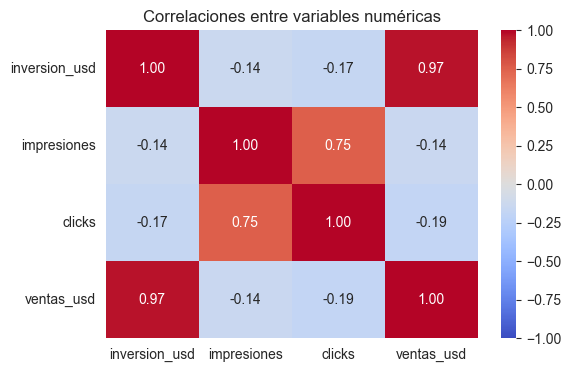

In [33]:
# Heatmap de correlación
numericas = df_clean.select_dtypes(include="number")
plt.figure(figsize=(6, 4))
sns.heatmap(numericas.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlaciones entre variables numéricas")
plt.show()

→ La correlación más fuerte con `ventas_usd` es `inversion_usd`. Es nuestro predictor.

## B.2 Definir X e y

`X` = predictor (`inversion_usd`), `y` = target (`ventas_usd`).

In [34]:
X = df_clean[["inversion_usd"]]
y = df_clean["ventas_usd"]

## B.3 Train / Test split

80% train / 20% test. Evaluamos sobre datos que el modelo nunca vio.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} filas  |  Test: {len(X_test)} filas")

Train: 71 filas  |  Test: 18 filas


## B.4 Entrenar el modelo

In [36]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecimos sobre el set de test
y_pred = modelo.predict(X_test)

## B.5 Evaluación

**MSE / RMSE** = error promedio (RMSE en USD). **R²** = qué % de la variabilidad explica el modelo (de 0 a 1).

In [37]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}  (en USD)")
print(f"R²   : {r2:.3f}")

MSE  : 126,874.02
RMSE : 356.19  (en USD)
R²   : 0.952


→ R² ≈ 0.95 → la inversión explica el 95% de la variabilidad de las ventas. RMSE ≈ $356 = error promedio de predicción en dólares.

## B.6 Coeficientes — interpretación

Fórmula original: $y = m \cdot x + b$

Aplicada a nuestro caso: $\text{ventas} = m \cdot \text{inversión} + b$

Donde `m` es lo que sube la venta por cada USD adicional invertido.

In [38]:
m = modelo.coef_[0]
b = modelo.intercept_
print(f"Pendiente (m): {m:.2f}")
print(f"Intercepto (b): {b:.2f}")
print()
print("Lectura de negocio:")
print(f"-> Por cada USD adicional invertido en marketing digital,")
print(f"   las ventas aumentan en promedio ${m:.2f}.")

Pendiente (m): 3.10
Intercepto (b): 543.40

Lectura de negocio:
-> Por cada USD adicional invertido en marketing digital,
   las ventas aumentan en promedio $3.10.


## B.7 Visualización — scatter + recta de regresión

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


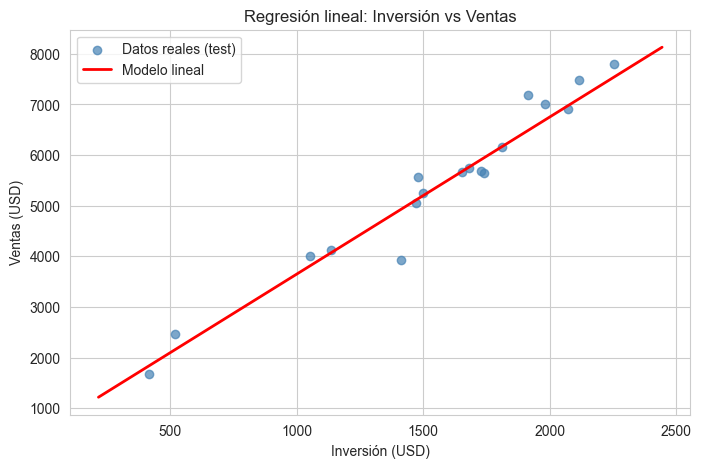

In [39]:
plt.figure(figsize=(8, 5))
# Datos reales (test)
plt.scatter(X_test, y_test, color="steelblue", label="Datos reales (test)", alpha=0.7)
# Recta del modelo
x_linea = np.linspace(X["inversion_usd"].min(), X["inversion_usd"].max(), 100).reshape(-1, 1)
plt.plot(x_linea, modelo.predict(x_linea), color="red", linewidth=2, label="Modelo lineal")
plt.title("Regresión lineal: Inversión vs Ventas")
plt.xlabel("Inversión (USD)")
plt.ylabel("Ventas (USD)")
plt.legend()
plt.show()

## B.8 Conclusión — volviendo a la pregunta de negocio

Arrancamos con dos preguntas. Las contestamos:

**¿Cuántos USD de venta generamos por cada USD invertido?**
→ ~**$3.10** en promedio (pendiente del modelo). Es el ROI marginal estimado y es el número que se le lleva al equipo de marketing.

**¿Podemos predecir las ventas a partir de la inversión?**
→ Sí. El modelo explica el **95%** de la variabilidad (R² = 0.95) y se equivoca en **±$356** (RMSE), ~7% de las ventas medianas. Suficiente para una primera estimación de presupuesto, **no** para decisiones finas sin un margen de seguridad.

---

# Para ver en casa
## 1. Overfitting vs Underfitting

Cualquier modelo puede tener dos problemas opuestos:

- **Overfitting (sobreajuste):** el modelo **aprende demasiado** los datos de entrenamiento, incluyendo el ruido y los detalles irrelevantes. Resultado: anda muy bien en train, pero **mal en datos nuevos** → no generaliza. *Ejemplo típico:* un modelo de ausentismo entrenado con datos de enero-marzo que acierta el 80% en esos meses, y cuando se prueba en agosto baja al 60%.
- **Underfitting (subajuste):** el modelo **aprende muy poco**, no captura los patrones importantes, es demasiado simple. Resultado: anda mal **en train y en datos nuevos**.

> El objetivo es encontrar un **equilibrio**: un modelo lo suficientemente expresivo para capturar el patrón real, pero no tanto como para memorizar el ruido. Por eso evaluamos siempre sobre el set de test (datos que el modelo nunca vio).

## 2. Supuestos, ventajas y limitaciones de la regresión lineal

**Supuestos (versión simple):**
- La relación entre `X` e `y` es **aproximadamente lineal**.
- No hay ruido extremo (los outliers afectan mucho — por eso los limpiamos en la Parte A).

**Ventajas:**
- **Fácil de entender** e interpretar (un coeficiente = un efecto en USD).
- **Rápido** de entrenar.
- Excelente como **baseline**: si un modelo más complejo no le gana a una regresión lineal, probablemente no vale la pena.

**Limitaciones:**
- Solo captura **relaciones lineales** — si el patrón real es una curva, se queda corto.
- **Sensible a outliers**: un solo valor extremo puede torcer toda la recta.
- **Puede quedarse corto** en problemas complejos con muchas variables interactuando.

## 3. Otros tipos de problemas de calidad de datos

En esta clase trabajamos con los 5 problemas más comunes (nulos, formatos, inconsistencias, outliers, duplicados). En el mundo real hay otros que también hay que vigilar, mencionados en el PDF:

- **Datos irrelevantes**: columnas que no aportan valor al análisis o al modelo.
- **Datos mal representados**: feature engineering pobre (ej. fechas como string en lugar de `datetime`, categorías que en realidad son ordinales).
- **Desbalance de clases**: en problemas de clasificación, una clase ocurre el 95% de las veces y la otra el 5% → el modelo aprende a predecir siempre la mayoritaria.
- **Data leakage**: información del futuro (o del target) "se cuela" en las variables predictoras → el modelo parece perfecto en pruebas pero falla en producción. Es uno de los errores más graves y más difíciles de detectar.
- **Datos desactualizados**: el dataset refleja un mundo que ya cambió.
- **Problemas de integración**: cuando se mergean fuentes distintas con formatos o granularidades diferentes.
- **Granularidad inconsistente**: una fila representa un día en algunas filas y una semana en otras.

## 4. Cómo mejorar este modelo

La regresión lineal simple que entrenamos es un **baseline**. Caminos para mejorarla, en orden de complejidad:

- **Sumar más variables predictoras** (`clicks`, `impresiones`, `canal`, `region`) → **regresión lineal múltiple**.
- **Feature engineering**: crear variables nuevas a partir de las existentes (ej. `CTR = clicks / impresiones`).
- **Validación cruzada** en lugar de un único train/test split, para tener una estimación más robusta del error.
- **Validar significancia estadística** de los coeficientes (p-values con `statsmodels`). Pueden ver un ejemplo de esto aplicado al mismo flujo (regresión lineal con dataset de salarios) en el notebook **`Lineal_Simple_Regression.ipynb`** que está en esta misma carpeta.
- **Probar otros modelos** cuando la relación no sea tan lineal: árboles de decisión, random forest, gradient boosting.

---

**Cierre.** Lo importante de esta clase: **el flujo no cambia**. Pregunta de negocio → datos limpios → elegir variables → entrenar → evaluar → interpretar. Lo que cambia es la herramienta y la complejidad del modelo.